In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polatory as p
import polatory.three as p3

def variog(m: p3.Model, diff: np.ndarray) -> float:
    v = m.nugget
    for rbf in m.rbfs:
        v += rbf.evaluate(np.zeros(3)) - rbf.evaluate(diff)
    return v

In [16]:
data = pd.read_csv("data/grade.csv")
points = data[["X", "Y", "Z"]].values
hole_ids = data["Hole ID"].values
values = data["Grade Values"].values
hids = np.unique(hole_ids)
hole_indices = np.array([np.where(hids == hid)[0] for hid in hole_ids])
set_ids = hole_indices % 2

In [17]:

directions = np.array(
    [
        [0.0,0.0,1.0],
        [0.10607892,0.32647735,0.9392336],
        [-0.27771825,0.20177411,0.9392336],
        [-0.18759248,0.57735026,0.79465449],
        [-0.55543649,0.40354821,0.72707576],
        [-0.44935754,0.73002559,0.51491791],
        [-0.72360682,0.52573109,0.44721359],
        [0.21215785,0.6529547,0.72707576],
        [-0.065560378,0.85472882,0.51491791],
        [0.2763932,0.85065079,0.44721359],
        [-0.27771825,-0.20177411,0.9392336],
        [-0.60706198,0.0,0.79465449],
        [-0.55543649,-0.40354821,0.72707576],
        [-0.83315468,-0.20177411,0.51491791],
        [-0.72360682,-0.52573109,0.44721359],
        [-0.83315468,0.20177411,0.51491791],
        [0.10607892,-0.32647735,0.9392336],
        [-0.18759248,-0.57735026,0.79465449],
        [0.21215785,-0.6529547,0.72707576],
        [-0.065560378,-0.85472882,0.51491791],
        [0.2763932,-0.85065079,0.44721359],
        [-0.44935754,-0.73002559,0.51491791],
        [0.34327862,0.0,0.9392336],
        [0.49112347,-0.3568221,0.79465449],
        [0.68655723,0.0,0.72707576],
        [0.79263616,-0.32647735,0.51491791],
        [0.89442718,0.0,0.44721359],
        [0.55543649,-0.6529547,0.51491791],
        [0.49112347,0.3568221,0.79465449],
        [0.55543649,0.6529547,0.51491791],
        [0.79263616,0.32647735,0.51491791],
        [0.10607892,0.97943211,0.17163931],
        [-0.30353099,0.93417233,0.18759248],
        [-0.66151541,0.73002559,0.17163931],
        [-0.89871508,0.40354821,0.17163931],
        [-0.98224694,0.0,0.18759248],
        [-0.89871508,-0.40354821,0.17163931],
        [-0.66151541,-0.73002559,0.17163931],
        [-0.30353099,-0.93417233,0.18759248],
        [0.10607892,-0.97943211,0.17163931],
        [0.48987609,-0.85472882,0.17163931],
        [0.79465449,-0.57735026,0.18759248],
        [0.96427548,-0.20177411,0.17163931],
        [0.96427548,0.20177411,0.17163931],
        [0.79465449,0.57735026,0.18759248],
        [0.48987609,0.85472882,0.17163931],
    ]
)

variogs = p3.VariogramCalculator(points, values, bin_interval=5.0, bin_tolerance=10.0, num_bins=200,
                                 angle_tolerance=np.radians(30.0), directions=directions).variograms

In [18]:
cov1 = p3.CovSpheroidal9([0.6, 75.0])
covs = [cov1]
m = p3.Model(covs, poly_degree=0)
# res = p3.cross_validation(m, points, values, set_ids, 1e-2)
# print("Residual before fitting:", np.linalg.norm(res))

best_fit = None
best_cost = float("inf")
for _ in range(30):
    weight = p.WeightFunction(exp_num_pairs=1.0, exp_distance=-2.0)
    fit = p.VarioFitting(variogs, m, weight)
    if fit.final_cost < best_cost:
        best_fit = fit
        best_cost = fit.final_cost

m = best_fit.model
# res = p3.cross_validation(m, points, values, set_ids, 1e-2)
# print("Residual after fitting:", np.linalg.norm(res))

Ceres Solver Report: Iterations: 22, Initial cost: 7.568494e-03, Final cost: 4.307978e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 26, Initial cost: 7.568494e-03, Final cost: 4.354893e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 31, Initial cost: 7.568494e-03, Final cost: 3.947442e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 8, Initial cost: 7.568494e-03, Final cost: 3.963891e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 15, Initial cost: 7.568494e-03, Final cost: 3.909339e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 16, Initial cost: 7.568494e-03, Final cost: 3.909336e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 16, Initial cost: 7.568494e-03, Final cost: 3.909338e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 17, Initial cost: 7.568494e-03, Final cost: 3.909336e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 22, Initial cost: 7.568494e-03, Final co

In [19]:
ea = np.degrees(best_fit.euler_angles)
pitch, dip, dip_az = ea
if dip < -90.0:
    dip += 180.0
    pitch = 180.0 - pitch
elif dip < 0.0:
    dip = -dip
    dip_az += 180.0
elif dip > 90.0:
    dip = 180.0 - dip
    dip_az += 180.0
    pitch = 180.0 - pitch
if dip_az < 0.0:
    dip_az += 360.0
elif dip_az > 360.0:
    dip_az -= 360.0
print("         dip      dip az       pitch")
print(f"  {dip:10.4f}  {dip_az:10.4f}  {pitch:10.4f}")

print("       psill         maj         mid         min")
nug = best_fit.parameters[0]
print(f"  {nug:10.4f}")
for i in range(len(covs)):
    psill = best_fit.parameters[1 + 2 * i]
    r = best_fit.parameters[1 + 2 * i + 1]
    maj = r / best_fit.scale(i)[0]
    mid = r / best_fit.scale(i)[1]
    min = r / best_fit.scale(i)[2]
    print(f"  {psill:10.4f}  {maj:10.4f}  {mid:10.4f}  {min:10.4f}")

         dip      dip az       pitch
     53.1976    105.6281     77.5930
       psill         maj         mid         min
      0.0861
      0.5461     80.3436     61.5381     36.3363


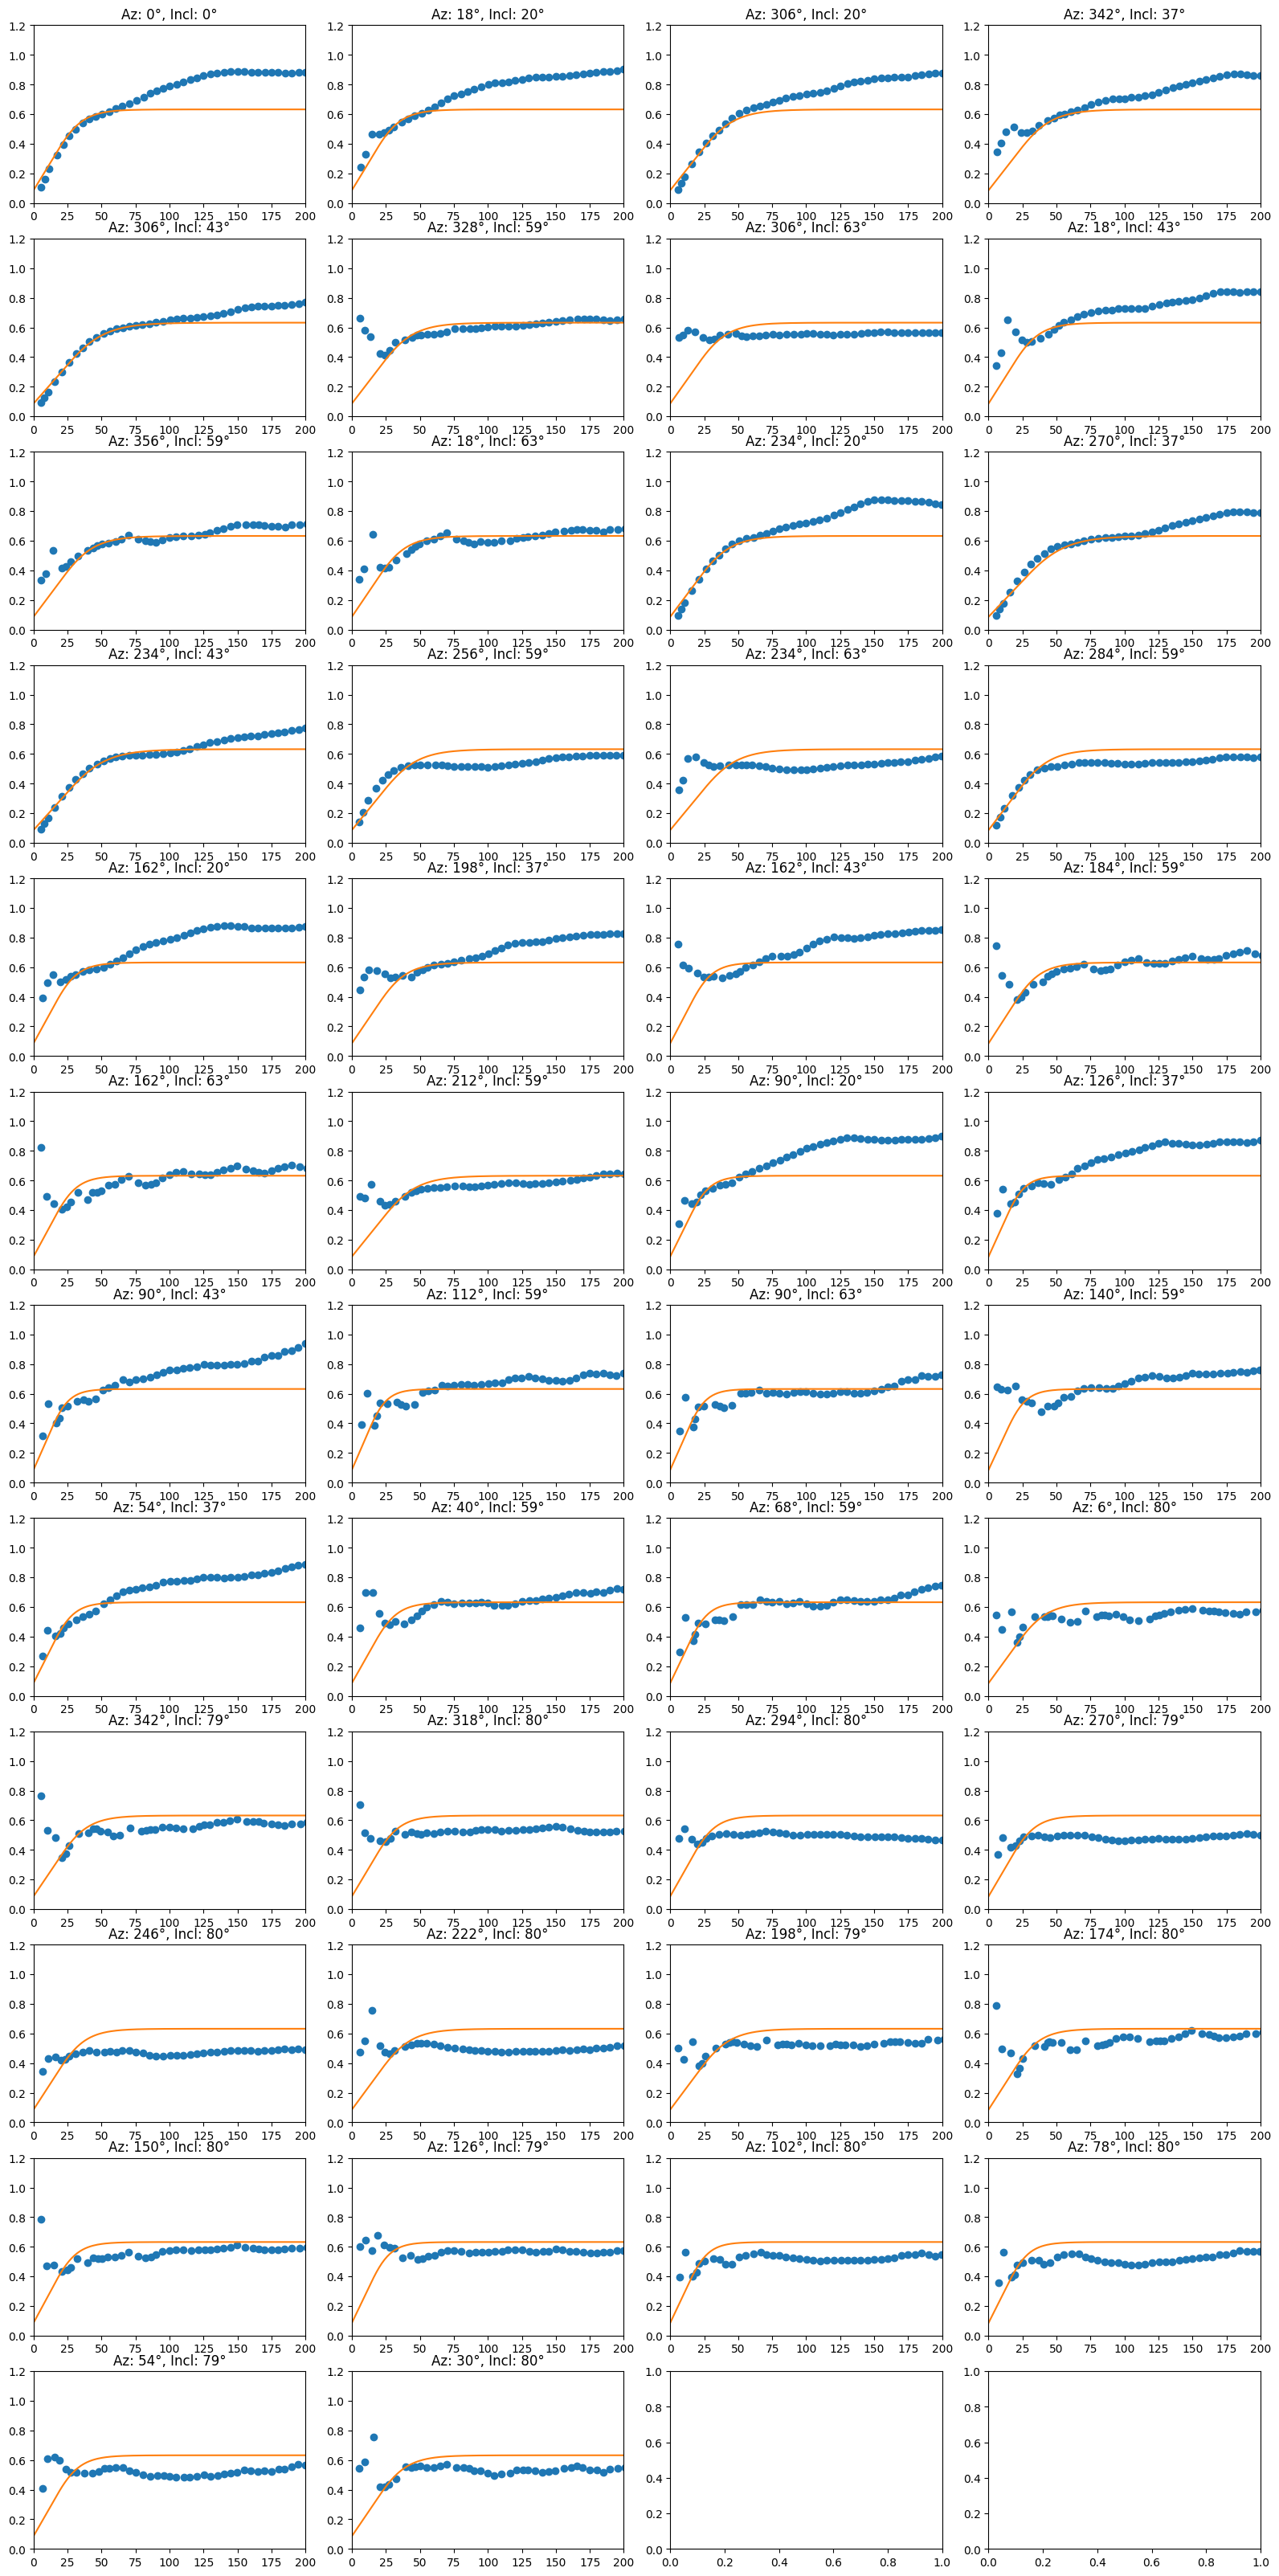

In [20]:

fig, ax = plt.subplots(nrows=12, ncols=4, figsize=(16, 32))
fig.tight_layout()
for i in range(12):
    for j in range(4):
        if 4 * i + j >= len(variogs):
            break
        v = variogs[4 * i + j]
        dir = v.direction
        az = np.degrees(np.arctan2(dir[0], dir[1]))
        if az < 0.0:
            az += 360.0
        incl = np.degrees(np.arccos(dir[2]))
        xs = np.linspace(0.0, 1000.0, 1000)
        ys = np.array([variog(m, x * dir) for x in xs])
        ax[i, j].plot(v.bin_distance, v.bin_gamma, "o")
        ax[i, j].plot(xs, ys, "-")
        ax[i, j].set_title(f"Az: {az:.0f}°, Incl: {incl:.0f}°")
        ax[i, j].set_xlim(0.0, 200.0)
        ax[i, j].set_ylim(0.0, 1.2)
        ax[i, j].margins(0.0)

In [21]:
inter = p3.Interpolant(m)
inter.fit(points, values, absolute_tolerance=1e-3)

In [ ]:
fn = p.RbfFieldFunction(inter)
bbox = p3.Bbox.from_points(points)
iso = p.Isosurface(bbox, resolution=5.0)
surf = iso.generate(fn, isovalue=1.0)
surf.export_obj("data/grade.obj")